# 直方圖 Histogram：


想像桌上有十張午餐發票：`60、70、80、80、90、100、100、110、120、160`。把地板畫成三個區間：60 到未滿 100、100 到未滿 140、140 到 180。學生拿發票站到對應區間，就得到 5、4、1 人。

| 區間 | 放進去的金額 | 次數 | 占十筆的比例 |
|---|---|---:|---:|
| [60, 100) | 60、70、80、80、90 | 5 | 50% |
| [100, 140) | 100、100、110、120 | 4 | 40% |
| [140, 180] | 160 | 1 | 10% |

`[` 表示包含這一端，`)` 表示不包含。100 不能同時分進兩組，否則總數會變大。Matplotlib／NumPy 的直方圖除最後一組外採左含右不含；最後一組包含右端點。此處 180 若出現，會放最後一組。

柱子的橫向位置是**數值區間**，高度先表示該區間有幾筆。直方圖不是把每一張發票畫成一根柱，也不是直接把所有金額加總。三個區間共有四個邊界，所以 `bins=[60,100,140,180]` 有三根柱。

## 直方圖、長條圖、折線圖怎麼選？

| 你想問的問題 | 適合圖形 | 原因 |
|---|---|---|
| 午餐 80～100 元的購買常見嗎？ | 直方圖 | 看連續數值的分布 |
| 飯、麵、便當各賣幾份？ | 長條圖 | 比較類別，類別順序可調整 |
| 我這個月每天花多少錢？ | 折線圖 | 要保留時間先後 |
| 通勤距離越遠是否越花時間？ | 散佈圖 | 要同時看兩個數值 |

直方圖橫軸不能把區間依高低重新排序，否則數字的位置關係被破壞。相鄰柱通常相接，是因為區間相連；是否留白只是外觀，並不是分辨圖形的唯一依據。直方圖也不保留哪一天發生，星期一與星期五交換後，圖可能完全相同。

## 五個會反覆使用的詞

- **分布：**資料在哪些地方多、哪些地方少，像觀察一群人站在哪些區域。
- **組界／組距：**分組的邊界／一組的寬度；`[0,10,20]` 的組距都是 10。
- **次數：**某組有幾筆；**相對次數：**該組筆數除以總筆數，乘 100 就是百分比。
- **樣本數 n：**本次看了幾筆；不是全世界總共有幾筆。只看 10 筆與看 1,000 筆，結論穩定性可能不同。
- **偏態：**較稀少的資料往哪個方向拖長尾巴。右偏是右邊有長尾，不是右邊的柱子最多。

讀圖時依序說出：橫軸與單位 → 縱軸與分母 → 樣本數 → 最密集區間 → 分散／尾巴 → 做決定還缺的資訊。不要只說「這張圖很漂亮」。


# 第一部分：Matplotlib

## 範例：午餐到底大多花多少：第一張直方圖

月底記帳只看總額很有壓力。先找出自己午餐最常出現的價位，才知道預算是否貼近日常。

**資料檔：** `Histogram_data/01_午餐花費.csv`  
**獨立範例檔：** `examples/01_午餐到底大多花多少.py`  
**一列代表：** 一筆午餐購買。詳細欄位與資料限制見 `Histogram_data/README.md`。

In [2]:
import pandas as pd

df = pd.read_csv("./Histogram_data/午餐花費.csv")
df.head()

,紀錄編號,午餐元
0,1,65
1,2,180
2,3,180
3,4,100
4,5,180


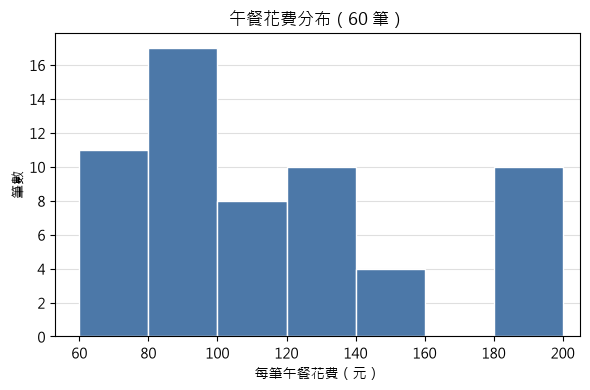

In [8]:
import matplotlib.pyplot as plt
import numpy as np

x = df['午餐元']
edges = np.arange(60, 201, 20)

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 4))
	counts, edges_used, patches = ax.hist(
		x,
		bins=edges,
		color="#4C78A8",
		edgecolor="white",
		linewidth=1
	) # 繪製直方圖

	# 標題與座標軸
	ax.set(
		title=f"午餐花費分布（{len(x)} 筆）",
		xlabel="每筆午餐花費（元）",
		ylabel="筆數"
	)

	# X 軸
	ax.set_xticks(edges)
	ax.set_xlim(53, 205)

	# Y 軸
	ax.set_ylim(bottom=0)
	ax.grid(axis="y", alpha=0.4) # 只顯示水平格線
	ax.set_axisbelow(True) # 讓格線放在柱子後方
	fig.tight_layout()
	plt.show()


## 範例：通勤看起來穩不穩：組數太少與太多

履歷上的上班地點看起來不遠，但每天通勤會不會差很多？一張圖切法不同，竟然會講出不同故事。

In [12]:
import pandas as pd

df = pd.read_csv("./Histogram_data/通勤時間.csv", encoding="utf-8-sig")
x = df[['通勤分鐘']]
x

,通勤分鐘
0,8.7
1,41.4
2,38.6
3,41.4
4,18.6
...,...
75,71.0
76,81.1
77,68.9
78,68.4


超過 60 分鐘的筆數： 9


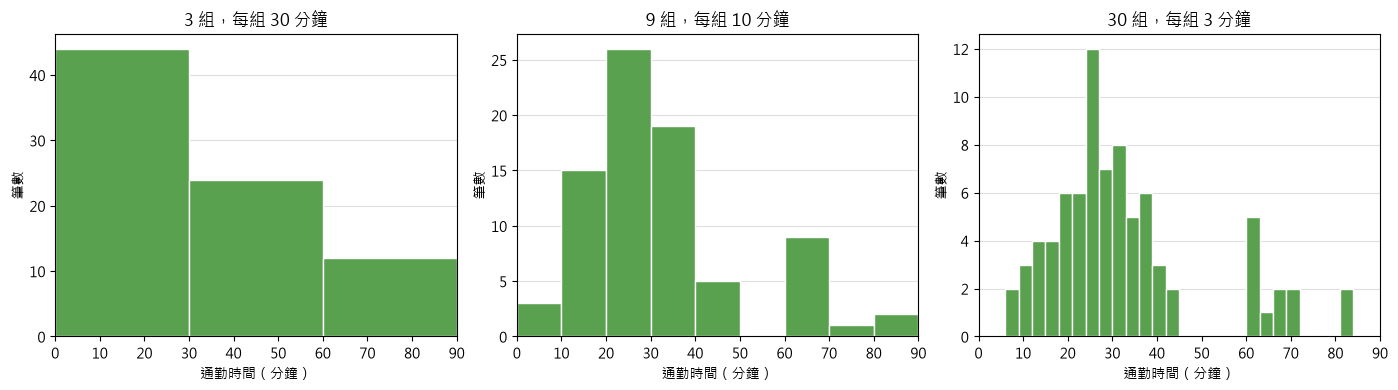

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


### 讀取資料
df = pd.read_csv("./Histogram_data/通勤時間.csv", encoding="utf-8-sig")
x = df["通勤分鐘"]


### 繪製不同組數的直方圖
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

	fig, axes = plt.subplots(1, 3, figsize=(14, 4))

	for ax, bins in zip(axes, [3, 9, 30]):
		ax.hist(
			x,
			bins=bins,
			range=(0, 90),
			color="#59A14F",
			edgecolor="white"
		) # 將 0～90 分鐘分成指定組數

		ax.set(
			title=f"{bins} 組，每組 {90 / bins:g} 分鐘",
			xlabel="通勤時間（分鐘）",
			ylabel="筆數"
		)

		ax.set_xlim(0, 90)
		ax.grid(axis="y", alpha=0.4) # 顯示水平格線
		ax.set_axisbelow(True) # 將格線放到柱子後方

	fig.tight_layout()

	print("超過 60 分鐘的筆數：", int((x > 60).sum()))

	plt.show()

### 範例：超市一買就破千：平均數與右偏

### 生活提問：這可以幹嘛？

家人說「一般買菜一次才幾百」，平均金額卻比較高。到底誰算錯？

**資料檔：** `Histogram_data/04_超市結帳.csv`  
**獨立範例檔：** `examples/04_超市一買就破千.py`  
**一列代表：** 一張結帳收據。詳細欄位與資料限制見 `Histogram_data/README.md`。



In [15]:
import pandas as pd

df = pd.read_csv("./Histogram_data/超市結帳.csv", encoding="utf-8-sig")
df.head()

,結帳元
0,939.0
1,634.0
2,1148.0
3,1125.0
4,499.0


千元以上比例：7.3%


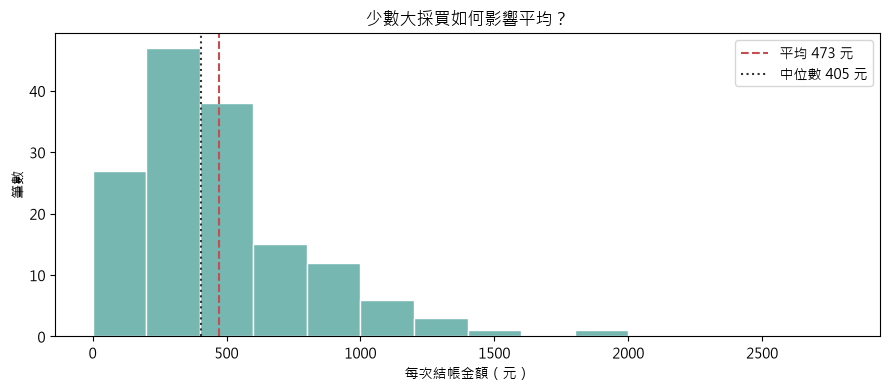

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


x = df["結帳元"]


### 繪製直方圖
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

	fig, ax = plt.subplots(figsize=(9, 4))

	ax.hist(
		x,
		bins=np.arange(0, 2801, 200),
		edgecolor="white",
		color="#76B7B2"
	)

	# 加入平均數與中位數
	ax.axvline(x.mean(), color="#C44E52", linestyle="--", label=f"平均 {x.mean():.0f} 元")
	ax.axvline(x.median(), color="#333333", linestyle=":", label=f"中位數 {x.median():.0f} 元")

	ax.set(
		title="少數大採買如何影響平均？",
		xlabel="每次結帳金額（元）",
		ylabel="筆數"
	)

	ax.legend()
	fig.tight_layout()

	print(f"千元以上比例：{(x >= 1000).mean():.1%}")

	plt.show()

### 範例：兩家早餐店誰比較快：樣本數不同先看比例

**資料檔：** `Histogram_data/05_早餐等候.csv`  
**獨立範例檔：** `examples/05_兩家早餐店誰比較快.py`  
**一列代表：** 一筆取餐訂單。詳細欄位與資料限制見 `Histogram_data/README.md`。

In [22]:
import pandas as pd

df = pd.read_csv("./Histogram_data/早餐等候.csv", encoding="utf-8-sig")
df.head()

,店家,等候分鐘
0,巷口店,7.4
1,巷口店,9.5
2,巷口店,11.7
3,巷口店,2.9
4,巷口店,8.4


千元以上比例：0.0%


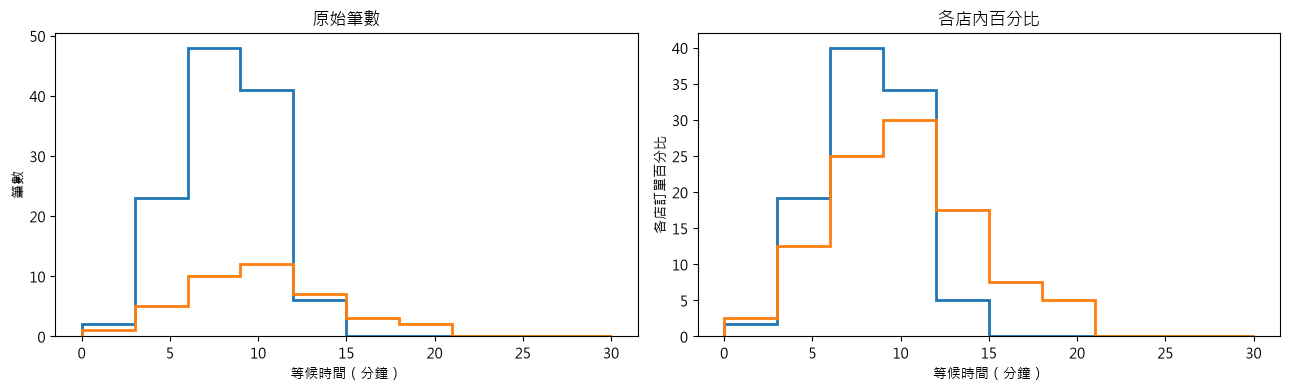

In [23]:
edges = np.arange(0, 31, 3)

### 繪製直方圖
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

	fig, axes = plt.subplots(1, 2, figsize=(13, 4))
	for shop, group in df.groupby('店家', sort=False):
		x = group['等候分鐘']
		axes[0].hist(x, bins=edges, histtype='step', linewidth=2, label=f'{shop} n={len(x)}')
		axes[1].hist(x, bins=edges, weights=np.full(len(x), 100 / len(x)),
					histtype='step', linewidth=2, label=f'{shop} n={len(x)}')
	axes[0].set(
		title="原始筆數",
		xlabel="等候時間（分鐘）",
		ylabel="筆數"
	)
	axes[1].set(
			title="各店內百分比",
			xlabel="等候時間（分鐘）",
			ylabel="各店訂單百分比"
		)
	ax.legend()
	fig.tight_layout()
	plt.show()


### 範例：一週煮幾天飯：整數資料對齊柱中心

想安排備餐課程，班上是完全不煮、偶爾煮，還是幾乎天天煮的人較多？

**資料檔：** `Histogram_data/08_每週煮飯天數.csv`  
**獨立範例檔：** `examples/08_一週煮幾天飯.py`  
**一列代表：** 一名填答者。詳細欄位與資料限制見 `Histogram_data/README.md`。

In [24]:
import pandas as pd

df = pd.read_csv("./Histogram_data/每週煮飯天數.csv", encoding="utf-8-sig")
x = df['每週煮飯天數']
x

0     1
1     0
2     5
3     3
4     4
     ..
95    4
96    2
97    4
98    4
99    3
Name: 每週煮飯天數, Length: 100, dtype: int64

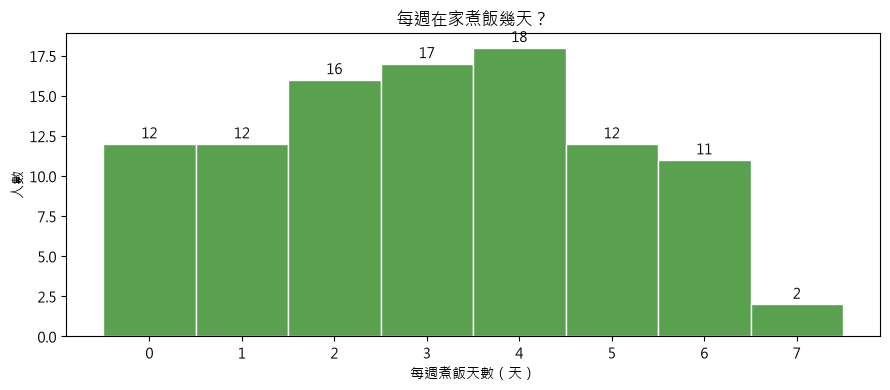

In [26]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 4))
	counts, _, bars = ax.hist(x, bins=np.arange(-.5, 8.5, 1), edgecolor='white', color='#59A14F')
	ax.bar_label(bars, labels=[str(int(n)) for n in counts], padding=3)
	ax.set_xticks(range(8))
	ax.set(
		title="每週在家煮飯幾天？",
		xlabel="每週煮飯天數（天）",
		ylabel="人數"
	)
	fig.tight_layout()
	plt.show()
	

### 範例：夏天電費壓力：完成一張可交付的比較圖

室友覺得夏天用電增加很多。能不能用相同分組，把春夏的差異講清楚，再把圖存給他看？

**資料檔：** `Histogram_data/10_租屋用電.csv`  
**獨立範例檔：** `examples/10_夏天電費壓力.py`  
**一列代表：** 一戶的一個月。詳細欄位與資料限制見 `Histogram_data/README.md`。


In [27]:
import pandas as pd

df = pd.read_csv("./Histogram_data/租屋用電.csv", encoding="utf-8-sig")
df
edges = np.arange(0, 551, 50)

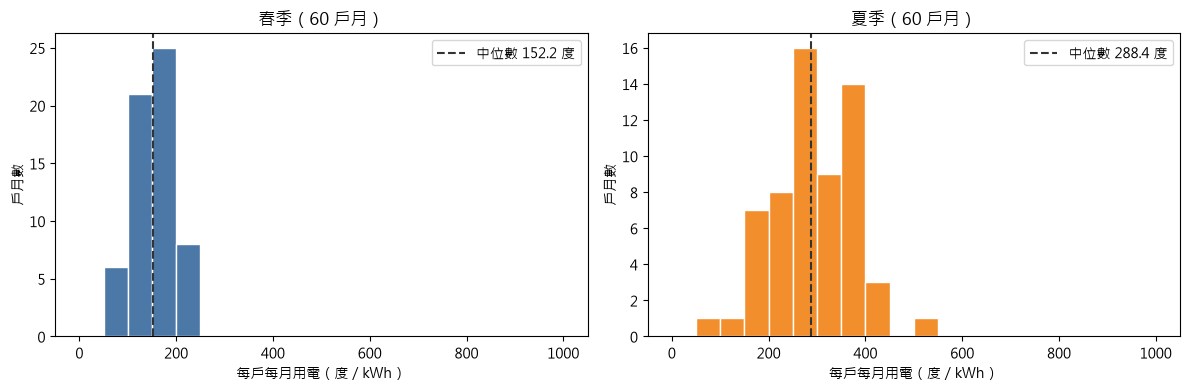

In [29]:
import matplotlib.pyplot as plt
import numpy as np


### 設定分組區間
edges = np.arange(0, 1001, 50)


### 繪製春季與夏季用電分布
with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

	fig, axes = plt.subplots(1, 2, figsize=(12, 4))

	for ax, season in zip(axes, ["春季", "夏季"]):
		# 取出該季節的每月用電資料
		x = df.loc[df["季節"].eq(season), "每月用電度"]

		# 繪製直方圖
		counts, _, bars = ax.hist(
			x,
			bins=edges,
			edgecolor="white",
			color="#F28E2B" if season == "夏季" else "#4C78A8"
		)

		# 標示中位數
		ax.axvline(
			x.median(),
			color="#333333",
			linestyle="--",
			label=f"中位數 {x.median():.1f} 度"
		)

		ax.set(
			title=f"{season}（{len(x)} 戶月）",
			xlabel="每戶每月用電（度／kWh）",
			ylabel="戶月數"
		)

		ax.legend()

	fig.tight_layout()
	plt.show()

# 第二部分：使用 Seaborn

你已知道分組與分母，接下來練習用資料表的欄位名稱描述問題。Seaborn 幫我們安排分組、圖例與分面，Matplotlib 仍負責標題、刻度、參考線與存檔。

| 想做什麼 | Seaborn 設定 | 先問自己 |
|---|---|---|
| 每組筆數 | `stat='count'` | 一列是一人、一單，還是彙總？ |
| 各組比例 | `stat='probability'` | 分母是誰？刻度是 0～1 |
| 百分比 | `stat='percent'` | 刻度是 0～100；是否各組各算？ |
| 面積代表比例 | `stat='density'` | 是否正在使用不等寬組距？ |
| 每單位的加權／未加權筆數 | `stat='frequency'` | 這是次數除以組距，並非比例 |
| 分組著色 | `hue='欄位'` | 組界與分母是否可比？ |
| 每組分開畫 | `displot(col=..., row=...)` | 小圖刻度與樣本數是否交代？ |

`stat='probability'`（亦可寫 proportion）讓組高合計為 1；`density` 讓面積合計為 1。只有組距剛好都是 1 時，兩者高度才可能一樣。先把中文意思說清楚，再選參數。


### 範例：早餐預算抓多少：Seaborn 第一張直方圖

### 生活提問：這可以幹嘛？
想把早餐控制在 80 元內，你需要看價格分布，也需要知道符合預算的筆數。

**資料檔：** `Histogram_data/11_早餐花費.csv`  
**獨立範例檔：** `examples/11_早餐預算抓多少.py`  
**一列代表：** 一筆早餐購買。詳細欄位與資料限制見 `Histogram_data/README.md`。



In [30]:
import pandas as pd

df = pd.read_csv("./Histogram_data/早餐花費.csv", encoding="utf-8-sig")
df

,早餐元
0,45
1,100
2,110
3,65
4,85
...,...
95,120
96,100
97,50
98,40


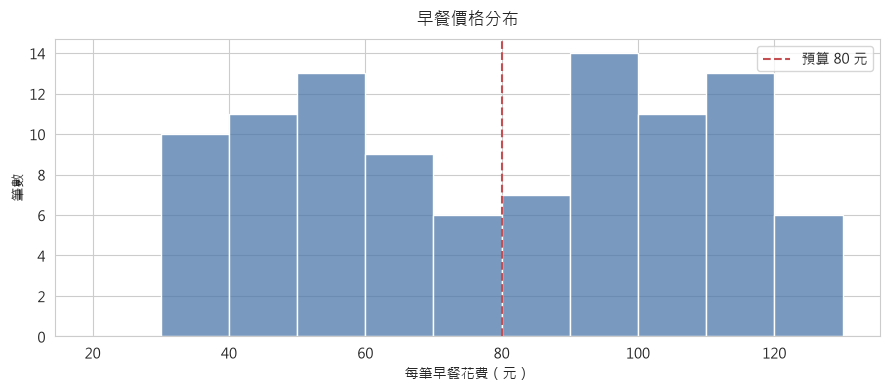

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 4))
	sns.histplot(data=df, x='早餐元', binwidth=10, binrange=(20, 130), stat='count', color='#4C78A8', ax=ax)
	ax.axvline(80, color='#C44E52', linestyle='--', label='預算 80 元')
	# 標題與軸標籤
	ax.set_title("早餐價格分布", fontsize=12, pad=10)
	ax.set_xlabel("每筆早餐花費（元）", fontsize=10)
	ax.set_ylabel("筆數", fontsize=10)
	ax.legend()
	fig.tight_layout()
	plt.show()

### 範例：手搖飲要避開假日嗎：hue 與透明疊圖

假日買飲料常覺得比較久。如何在同一張圖看平日與假日的等待區間？

**資料檔：** `Histogram_data/12_手搖飲等待.csv`  
**獨立範例檔：** `examples/12_手搖飲要避開假日嗎.py`  
**一列代表：** 一筆手搖飲訂單。詳細欄位與資料限制見 `Histogram_data/README.md`。


In [34]:
import pandas as pd

df = pd.read_csv("./Histogram_data/手搖飲等待.csv", encoding="utf-8-sig")
df

,時段,等候分鐘
0,平日,0.5
1,平日,10.1
2,平日,8.0
3,平日,6.1
4,平日,4.8
...,...,...
195,假日,8.0
196,假日,7.8
197,假日,11.9
198,假日,11.3


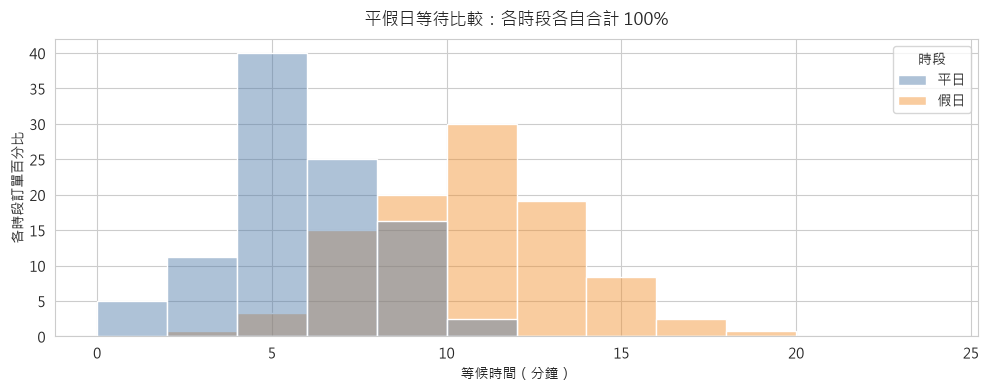

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(10, 4))
	sns.histplot(data=df, x='等候分鐘', hue='時段', hue_order=['平日', '假日'],
				palette={'平日': '#4C78A8', '假日': '#F28E2B'}, bins=np.arange(0, 26, 2),
				stat='percent', common_norm=False, common_bins=True, multiple='layer', alpha=.45, ax=ax)
	# 標題與軸標籤
	ax.set_title("平假日等待比較：各時段各自合計 100%", fontsize=12, pad=10)
	ax.set_xlabel("等候時間（分鐘）", fontsize=10)
	ax.set_ylabel("各時段訂單百分比", fontsize=10)
	fig.tight_layout()
	plt.show()

### 範例：自備與外食差多少：common_norm 的分母陷阱

自備只有 90 筆，外食有 150 筆。你想問「各自通常花多少」，還是「全部午餐裡各方式占多少」？

**資料檔：** `Histogram_data/13_午餐取得方式.csv`  
**獨立範例檔：** `examples/13_自備與外食差多少.py`  
**一列代表：** 一筆午餐。詳細欄位與資料限制見 `Histogram_data/README.md`。

In [39]:
import pandas as pd

df = pd.read_csv("./Histogram_data/午餐取得方式.csv", encoding="utf-8-sig")
df

,取得方式,午餐元
0,自備,50.3
1,自備,46.0
2,自備,72.2
3,自備,33.2
4,自備,48.8
...,...,...
235,外食,88.2
236,外食,98.2
237,外食,112.5
238,外食,119.1


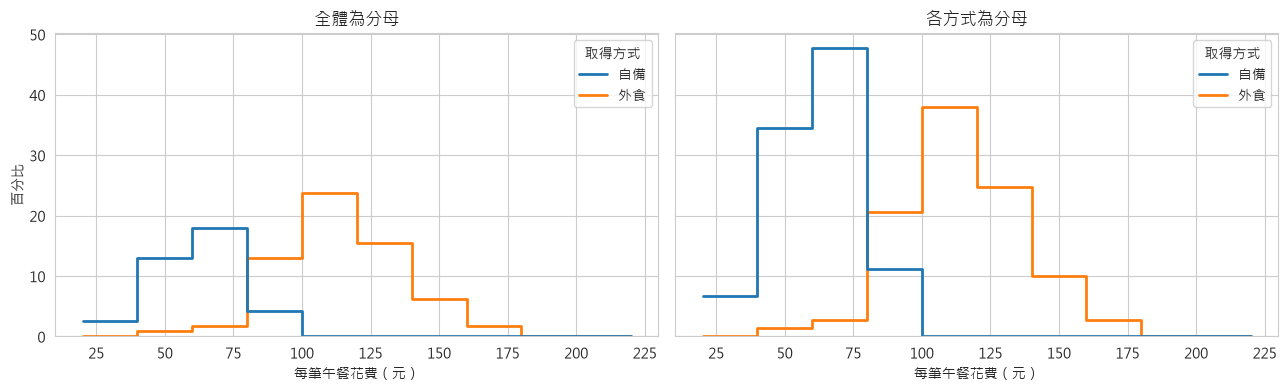

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. 繪圖設定與 Seaborn 樣式
with sns.axes_style("whitegrid"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei"  # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False          # 避免負號顯示異常

	fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

	# 3. 迴圈繪製
	for ax, common in zip(axes, [True, False]):
		sns.histplot(
			data=df,
			x='午餐元',
			hue='取得方式',
			hue_order=['自備', '外食'],
			bins=np.arange(20, 221, 20),
			stat='percent',
			common_norm=common,
			common_bins=True,
			element='step',
			fill=False,
			linewidth=2,
			ax=ax
		)
		# 直接使用 ax.set() 設定標題與軸標籤
		ax.set(
			title='全體為分母' if common else '各方式為分母',
			xlabel='每筆午餐花費（元）',
			ylabel='百分比'
		)
	fig.tight_layout()
	plt.show()

### 範例：三種通勤方式：改用小圖避免重疊

三種交通工具疊在一起看不清楚。把它們各放一張圖，還能公平比較嗎？

**資料檔：** `Histogram_data/15_通勤方式.csv`  
**獨立範例檔：** `examples/15_三種通勤方式.py`  
**一列代表：** 一名通勤者的一次通勤。詳細欄位與資料限制見 `Histogram_data/README.md`。


In [46]:
import pandas as pd

df = pd.read_csv("./Histogram_data/通勤方式.csv", encoding="utf-8-sig")
df

,通勤方式,通勤分鐘
0,公車,37.1
1,公車,36.4
2,公車,55.3
3,公車,34.7
4,公車,55.8
...,...,...
205,機車,10.1
206,機車,32.6
207,機車,15.6
208,機車,19.3


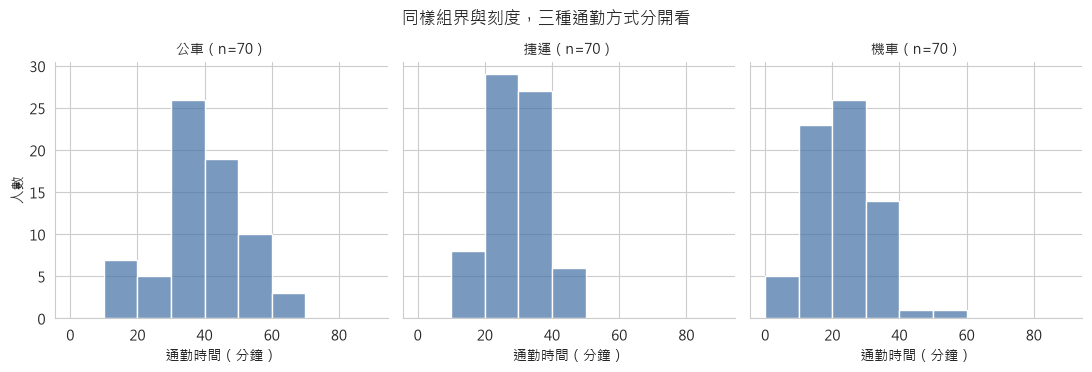

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	g = sns.displot(data=df, x='通勤分鐘', col='通勤方式', col_order=['公車', '捷運', '機車'],
					col_wrap=3, bins=np.arange(0, 91, 10), stat='count', height=3.5, aspect=1.05,
					facet_kws={'sharex': True, 'sharey': True}, color='#4C78A8')
	g.set_axis_labels('通勤時間（分鐘）', '人數')
	g.set_titles('{col_name}（n=70）')
	g.figure.suptitle('同樣組界與刻度，三種通勤方式分開看', y=1.05)
	plt.show()

### 範例：一週外食幾次：discrete 與零次的意義

想減少外食，先看看一週午晚餐十四餐，大家外食幾次。零次的人要不要算？

**資料檔：** `Histogram_data/17_每週外食次數.csv`  
**獨立範例檔：** `examples/17_一週外食幾次.py`  
**一列代表：** 一名填答者。詳細欄位與資料限制見 `Histogram_data/README.md`。


In [49]:
import pandas as pd

df = pd.read_csv("./Histogram_data/每週外食次數.csv", encoding="utf-8-sig")
df

,每週外食次數
0,9
1,4
2,10
3,5
4,0
...,...
115,7
116,12
117,5
118,12


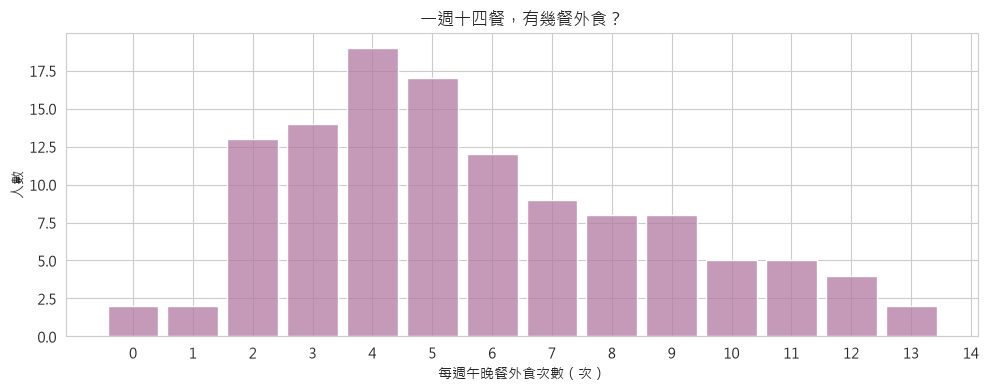

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(10, 4))
	sns.histplot(data=df, x='每週外食次數', discrete=True, shrink=.85, stat='count', color='#B279A2', ax=ax)
	ax.set_xticks(range(15))
	ax.set(
		title='一週十四餐，有幾餐外食？',
		xlabel='每週午晚餐外食次數（次）',
		ylabel='人數'
	)
	fig.tight_layout()
	plt.show()


### 範例：團購雞蛋：一列不一定等於一盒

團購表只有十列價格，但實際訂了一百盒。直接畫十列，會不會把最常買的價位看錯？

**資料檔：** `Histogram_data/19_團購雞蛋份數.csv`  
**獨立範例檔：** `examples/19_團購雞蛋.py`  
**一列代表：** 一個價格及其合計盒數。詳細欄位與資料限制見 `Histogram_data/README.md`。


In [52]:
import pandas as pd

df = pd.read_csv("./Histogram_data/團購雞蛋份數.csv", encoding="utf-8-sig")
df

,每盒價格元,訂購盒數
0,65,2
1,70,5
2,75,8
3,80,20
4,85,25
5,90,18
6,95,10
7,100,6
8,110,4
9,120,2


表格列數： 10 實際總盒數： 100
各組盒數： [ 2 13 45 28  6  4  2  0]


C:\Users\User\AppData\Local\Temp\ipykernel_7056\2913532411.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


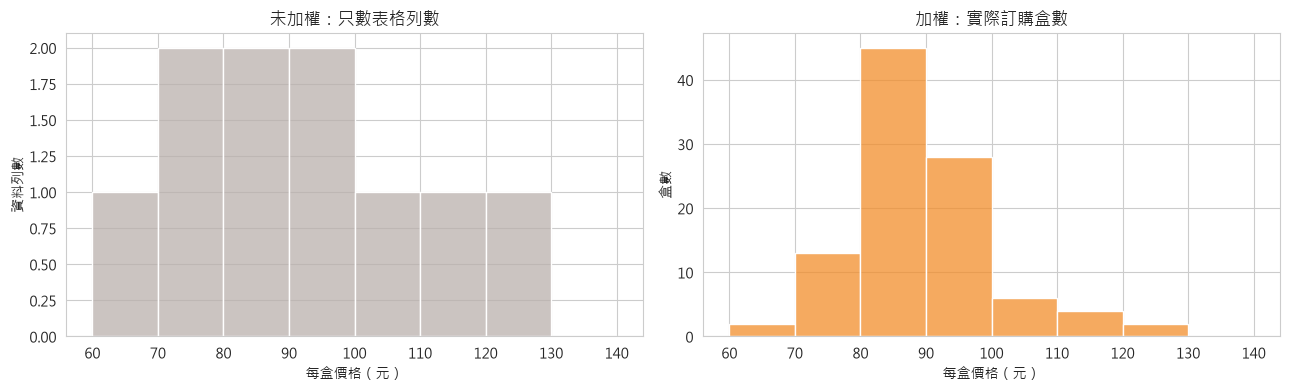

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

edges = np.arange(60, 141, 10)

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, layout="constrained")

	# 左圖：未加權
	sns.histplot(data=df, x='每盒價格元', bins=edges, stat='count', color='#BAB0AC', ax=axes[0])
	axes[0].set(title='未加權：只數表格列數', xlabel='每盒價格（元）', ylabel='資料列數')

	# 右圖：加權
	# Seaborn 0.13.2 的 weights 搭配自訂組界時，用 Python list 避免陣列判斷相容性問題。
	sns.histplot(data=df, x='每盒價格元', weights='訂購盒數', bins=edges.tolist(), stat='count', color='#F28E2B', ax=axes[1])
	axes[1].set(title='加權：實際訂購盒數', xlabel='每盒價格（元）', ylabel='盒數')

	expanded = np.repeat(df['每盒價格元'].to_numpy(), df['訂購盒數'].to_numpy())
	weighted, _ = np.histogram(df['每盒價格元'], bins=edges, weights=df['訂購盒數'])
	unpacked, _ = np.histogram(expanded, bins=edges)
	assert np.array_equal(weighted, unpacked)

	print('表格列數：', len(df), '實際總盒數：', df['訂購盒數'].sum())
	print('各組盒數：', weighted)

	fig.tight_layout()
	plt.show()